## Lab 3 - Data Pre-preocessing
### 02 February 2026
##### In this lab, we will learn the essential skill of data preprocessing: cleaning, transforming, and engineering features so that our ML models perform at their best.


In [ ]:
# Part 1 - Setting up messy dataset

import pandas as pd
import numpy as np
np . random . seed (42)
n = 200
data = {'age': np.random.randint(18,80,n).astype(float),
'blood_pressure': np.round(np.random.uniform(90,180,n),1),
'cholesterol': np.round(np.random.uniform(150,350,n),1) ,
'bmi': np.round(np.random.uniform(18,42,n),1),
'gender': np.random.choice(['Male','Female'],n) ,
'city': np.random.choice(
['Jeddah', 'Riyadh','Dammam', 'Makkah'],n),
'smoker': np.random.choice(['Yes','No'],n,p =[0.3 , 0.7]),
'heart_disease': np.random.choice([0,1],n,p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
# Inject missing values ( realistic !)
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age'] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure'] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol'] = np . nan
print ( f'Dataset shape : {df. shape }')
print ( f'\n First 5 rows :')
print ( df . head () )
print ( f'\n Missing values per column :')
print ( df.isnull().sum())


Dataset shape : (200, 8)

 First 5 rows :
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

 Missing values per column :
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [ ]:
# Part 2 - Identifying the Issues

print ('=== Data Types === ')
print ( df . dtypes )
print ('\n=== Missing Values === ')
print ( df . isnull () .sum () )
print ('\n=== Numeric Ranges ( notice the scale differences !) === ')
print ( df . describe () . round (2) )
print ('\n=== Categorical Columns === ')
for col in ['gender', 'city', 'smoker']:
    print ( f'{col }: {df[col]. unique ()}')

=== Data Types === 
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values === 
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges ( notice the scale differences !) === 
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75  

In [ ]:
# Task 1 - Exploring the messy data
df.info()
df.isnull().mean() * 100
df['city'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


,count
city,
Dammam,59
Jeddah,52
Riyadh,47
Makkah,42


In [ ]:
# Part 3 - Impute Numeric Columns
from sklearn . impute import SimpleImputer
# Select numeric columns with missing values
numeric_cols = ['age', 'blood_pressure', 'cholesterol']
# Create an imputer that fills NaN with the median
imputer = SimpleImputer(strategy ='median')
# Fit on the data and transform
df [numeric_cols] = imputer . fit_transform ( df [ numeric_cols ])
# Verify : no more missing values !
print ('Missing values after imputation :')
print (df[ numeric_cols ].isnull ().sum () )


Missing values after imputation :
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [ ]:
# Part 4 - Verifying the fixes
print(f'Total missing values in entire dataset : {df. isnull ().sum ().sum()}')
print(f'\n Dataset shape (no rows lost !): {df. shape }')
print(df.describe().round(2))


Total missing values in entire dataset : 0

 Dataset shape (no rows lost !): (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


In [ ]:
# Task 2.1 - Recreating Messy Database
np.random.seed(42)
n = 200
data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df = pd.DataFrame(data)

# Inject missing values
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print("Original missing values:")
print(df.isnull().sum())


Original missing values:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [ ]:
# Task 2.2 - Mean Imputation
numeric_cols = ['age', 'blood_pressure', 'cholesterol']
imputer_mean = SimpleImputer(strategy='mean')
df_mean_filled = df.copy()
df_mean_filled[numeric_cols] = imputer_mean.fit_transform(df_mean_filled[numeric_cols])

print("\n=== MEAN IMPUTATION RESULTS ===")
print("Missing values after mean imputation:")
print(df_mean_filled[numeric_cols].isnull().sum())



=== MEAN IMPUTATION RESULTS ===
Missing values after mean imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [ ]:
# 2.3 - ADDITIONAL Code from Comparing
imputer_median = SimpleImputer(strategy='median')
df_median_filled = df.copy()
df_median_filled[numeric_cols] = imputer_median.fit_transform(df_median_filled[numeric_cols])

# Show differences at imputed positions
print("\n=== MEAN vs MEDIAN COMPARISON (at NaN positions) ===")
age_diff = df_mean_filled.loc[df['age'].isnull(), 'age'].mean() - df_median_filled.loc[df['age'].isnull(), 'age'].mean()
bp_diff = df_mean_filled.loc[df['blood_pressure'].isnull(), 'blood_pressure'].mean() - df_median_filled.loc[df['blood_pressure'].isnull(), 'blood_pressure'].mean()
chol_diff = df_mean_filled.loc[df['cholesterol'].isnull(), 'cholesterol'].mean() - df_median_filled.loc[df['cholesterol'].isnull(), 'cholesterol'].mean()

print(f"Age: mean-median diff = {age_diff:.2f}")
print(f"Blood Pressure: mean-median diff = {bp_diff:.2f}")
print(f"Cholesterol: mean-median diff = {chol_diff:.2f}")

print("\nDataset summary after mean imputation:")
print(df_mean_filled.describe().round(2))



=== MEAN vs MEDIAN COMPARISON (at NaN positions) ===
Age: mean-median diff = -0.69
Blood Pressure: mean-median diff = -2.17
Cholesterol: mean-median diff = -3.22

Dataset summary after mean imputation:
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.23           26.14        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     49.31          136.85       252.79   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


In [ ]:
# Task 2.4 - Dropping Rows
df_dropna = df.dropna()
rows_lost = len(df) - len(df_dropna)
print(f"\n Rows lost with dropna(): {rows_lost} ({rows_lost/len(df)*100:.1f}%)")
print(f"Dropna shape: {df_dropna.shape}")


 Rows lost with dropna(): 20 (10.0%)
Dropna shape: (180, 8)


##### Dropped rows: 20
##### If 20 rows are lost, then 10% of the data is lost which I think is not acceptable

In [ ]:
# Part 5.1
# Label Encoding for Binary Variables
from sklearn . preprocessing import LabelEncoder
# Encode gender : Female =0 , Male =1
le_gender = LabelEncoder ()
df ['gender_encoded'] = le_gender.fit_transform (df['gender'])
# Encode smoker : No =0 , Yes =1
le_smoker = LabelEncoder ()
df ['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])
print ('Original vs Encoded :')
print ( df [['gender', 'gender_encoded','smoker', 'smoker_encoded']]. head (8))

Original vs Encoded :
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1


In [ ]:
# ADDITONAL - saving city column so it can be added again for use later
city_original = df['city'].copy()

In [ ]:
# Part 5.2
# One-Hot Encode the city column
city_dummies=pd.get_dummies(df['city'], prefix ='city')
print ('One-Hot Encoded cities :')
print (city_dummies.head())
# Add to dataframe and drop original text columns
df = pd.concat([df,city_dummies],axis=1)
df = df.drop(columns=['gender','city','smoker'])
print ( f'\n New columns : { list (df.columns)}')

One-Hot Encoded cities :
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

 New columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


In [ ]:
# ADDITONAL - adding city column back for use
df['city'] = city_original

In [ ]:
# Task 3.1 - Printing first 10 rows
print("First 10 rows of fully encoded dataset:")
print(df.head(10))
print(f"\nNumber of columns now: {len(df.columns)}")
print(f"Column names: {list(df.columns)}")

First 10 rows of fully encoded dataset:
    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh    city  
0               0        False  

In [ ]:
# Task 3.2 - 50 Unique Cities Scenario
pd.get_dummies(df['city'])

,Dammam,Jeddah,Makkah,Riyadh
0,False,False,False,True
1,True,False,False,False
2,False,True,False,False
3,False,False,False,True
4,False,False,True,False
...,...,...,...,...
195,False,False,True,False
196,False,True,False,False
197,True,False,False,False
198,False,False,True,False


##### One-hot encoding 50 cities creates 50 new columns.
##### This causes high memory use.
##### It slows training.
##### It risks overfitting.

In [ ]:
# Bonus: drop_first=True version
city_dummies_drop = pd.get_dummies(df['city'], prefix='city', drop_first=True)
print("One-hot with drop_first=True (3 columns instead of 4):")
print(city_dummies_drop.head())
print(f"Shape: {city_dummies_drop.shape}")

One-hot with drop_first=True (3 columns instead of 4):
   city_Jeddah  city_Makkah  city_Riyadh
0        False        False         True
1        False        False        False
2         True        False        False
3        False        False         True
4        False         True        False
Shape: (200, 3)


##### Drops 1 column (first alphabetically).
##### Eliminates multicollinearity.
##### Uses n-1 columns instead of n.
##### Prevents coefficient instability.

In [ ]:
# Part 6.1 - Applying StandardScaler

from sklearn . preprocessing import StandardScaler
from sklearn . impute import SimpleImputer # Import SimpleImputer again

# Impute missing values for the current df (re-apply imputation as df was recreated)
numeric_cols = ['age', 'blood_pressure', 'cholesterol']
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Convert boolean one-hot encoded columns to int type
for col in ['city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']:
    df[col] = df[col].astype(int)

# Prepare features and target
feature_cols = ['age','blood_pressure','cholesterol','bmi',
'gender_encoded', 'smoker_encoded',
'city_Dammam', 'city_Jeddah',
'city_Makkah', 'city_Riyadh']
X = df [ feature_cols ]. values
y = df ['heart_disease']. values

# Scale the features
scaler = StandardScaler ()
X_scaled = scaler . fit_transform ( X )

# Compare before and after
import pandas as pd
comparison = pd . DataFrame ({
'Feature': feature_cols ,
'Original Mean': X . mean ( axis =0) . round (2) ,
'Original Std': X . std ( axis =0) . round (2) ,
'Scaled Mean': X_scaled . mean ( axis =0) . round (2) ,
'Scaled Std': X_scaled . std ( axis =0) . round (2)
})
print ( comparison . to_string ( index = False ) )

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


/tmp/ipython-input-1215/1797960050.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
/tmp/ipython-input-1215/1797960050.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,


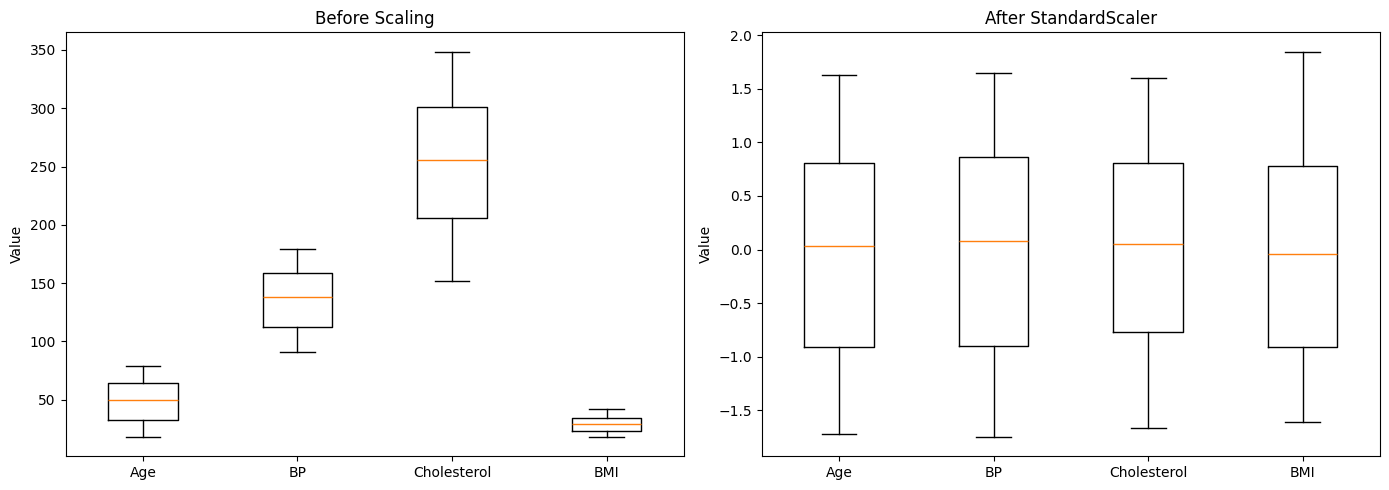

In [ ]:
# Task 6.2 -  Visualize the Effect of Scaling

import matplotlib . pyplot as plt
fig , axes = plt . subplots (1 , 2 , figsize =(14 , 5) )
# Before scaling
axes [0]. boxplot ([ X [: , 0] , X [: , 1] , X [: , 2] , X [: , 3]] ,
labels =[ 'Age', 'BP', 'Cholesterol', 'BMI'])
axes [0]. set_title ('Before Scaling')
axes [0]. set_ylabel ('Value')
# After scaling
axes [1]. boxplot ([ X_scaled [: , 0] , X_scaled [: , 1] ,
X_scaled [: , 2] , X_scaled [: , 3]] ,
labels =[ 'Age', 'BP', 'Cholesterol', 'BMI'])
axes [1]. set_title ('After StandardScaler')
axes [1]. set_ylabel ('Value')
plt . tight_layout ()
plt . show ()


In [ ]:
# Task 4.1 - Appliying MinMaxScalar
from sklearn.preprocessing import MinMaxScaler

# Use the same prepared data from StandardScaler section
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

# Compare before and after
comparison_minmax = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': X.mean(axis=0).round(2),
    'Original Std': X.std(axis=0).round(2),
    'MinMax Mean': X_minmax.mean(axis=0).round(2),
    'MinMax Std': X_minmax.std(axis=0).round(2),
    'MinMax Min': X_minmax.min(axis=0).round(2),
    'MinMax Max': X_minmax.max(axis=0).round(2)
})
print(comparison_minmax.to_string(index=False))


       Feature  Original Mean  Original Std  MinMax Mean  MinMax Std  MinMax Min  MinMax Max
           age          49.34         18.19         0.51        0.30         0.0         1.0
blood_pressure         136.08         26.08         0.51        0.29         0.0         1.0
   cholesterol         252.36         60.05         0.51        0.31         0.0         1.0
           bmi          29.33          6.87         0.47        0.29         0.0         1.0
gender_encoded           0.52          0.50         0.52        0.50         0.0         1.0
smoker_encoded           0.32          0.47         0.32        0.47         0.0         1.0
   city_Dammam           0.30          0.46         0.30        0.46         0.0         1.0
   city_Jeddah           0.26          0.44         0.26        0.44         0.0         1.0
   city_Makkah           0.21          0.41         0.21        0.41         0.0         1.0
   city_Riyadh           0.24          0.42         0.24        0.42  

##### Expected output shows all values between 0.00 and 1.00. Age (18-80) becomes 0-1, blood pressure (90-180) becomes 0-1, etc.

/tmp/ipython-input-1215/889899579.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-1215/889899579.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], X_scaled[:, 3]],
/tmp/ipython-input-1215/889899579.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([X_minmax[:, 0], X_minmax[:, 1], X_minmax[:, 2], X_minmax[:, 3]],


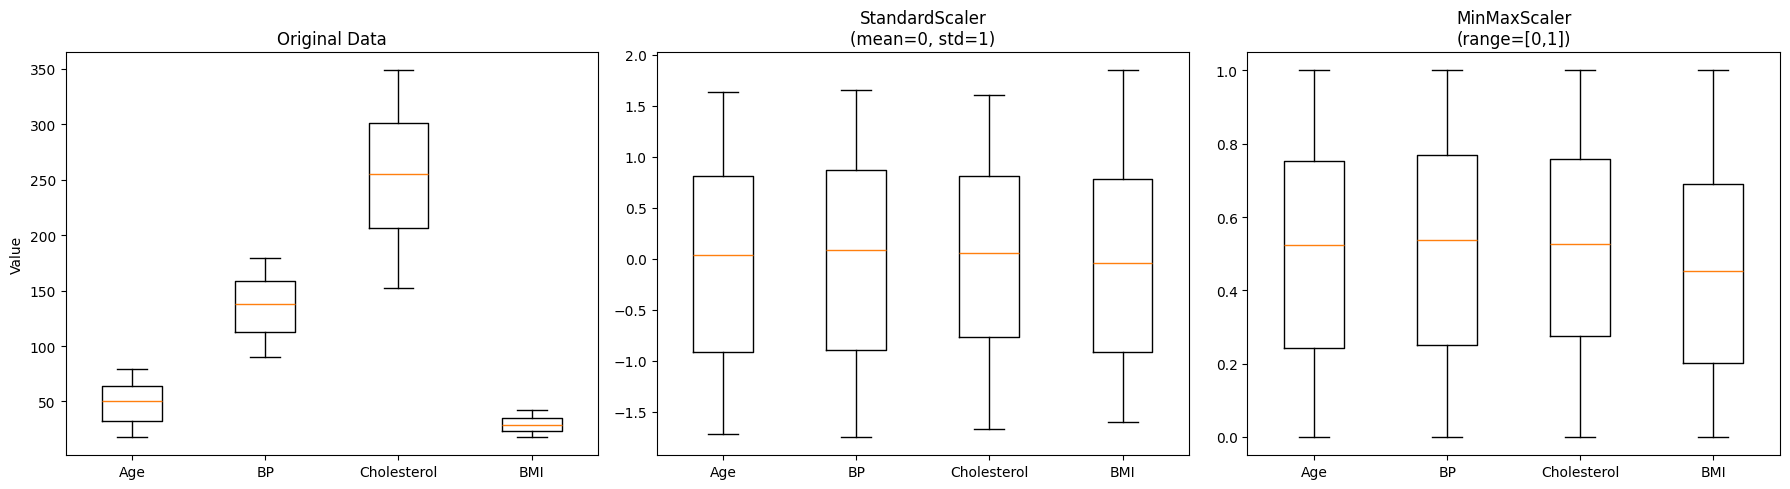

In [ ]:
# Task 4.2 - Creating the box plot for MinMaxScalar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Original Data')
axes[0].set_ylabel('Value')

# StandardScaler (from previous code)
axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], X_scaled[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('StandardScaler\n(mean=0, std=1)')

# MinMaxScaler
axes[2].boxplot([X_minmax[:, 0], X_minmax[:, 1], X_minmax[:, 2], X_minmax[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[2].set_title('MinMaxScaler\n(range=[0,1])')

plt.tight_layout()
plt.show()


##### StandardScaler centers data around 0 with unit variance. MinMaxScaler squeezes everything into regardless of original distribution.


#### Task 4.3 - Outlier Robustness
##### MinMaxScaler is LESS robust to outliers. A single extreme value (like age=150) becomes 1.0, compressing all other values toward 0 and distorting relationships. StandardScaler is MORE robust. Outliers extend whiskers but don't squash the rest of the data since it uses mean/std, not min/max.
##### Recommendation: Use RobustScaler (median + IQR) for datasets with outliers. Your medical data likely has outliers in cholesterol/blood pressur

In [ ]:
# Part 7.1 - Experiment: KNN Without Scaling vs. With Scaling

from sklearn . model_selection import train_test_split
from sklearn . neighbors import KNeighborsClassifier
from sklearn . metrics import accuracy_score
# Split data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
X_train_s , X_test_s , _ , _ = train_test_split (
X_scaled , y , test_size =0.2 , random_state =42 , stratify = y )
# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier ( n_neighbors =5)
knn_raw . fit ( X_train , y_train )
raw_acc = accuracy_score ( y_test , knn_raw . predict ( X_test ) )
# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier ( n_neighbors =5)
knn_scaled . fit ( X_train_s , y_train )
scaled_acc = accuracy_score ( y_test , knn_scaled . predict ( X_test_s ) )
print ( f'KNN Accuracy WITHOUT scaling : { raw_acc :.2%} ')
print ( f'KNN Accuracy WITH scaling : { scaled_acc :.2%} ')
print ( f'Improvement : {( scaled_acc - raw_acc ) :.2%} ')


KNN Accuracy WITHOUT scaling : 67.50% 
KNN Accuracy WITH scaling : 50.00% 
Improvement : -17.50% 


In [ ]:
# Part 7.2 - Decision Tree Comparision

from sklearn . tree import DecisionTreeClassifier
# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier ( random_state =42)
dt_raw . fit ( X_train , y_train )
dt_raw_acc = accuracy_score ( y_test , dt_raw . predict ( X_test ) )
# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier ( random_state =42)
dt_scaled . fit ( X_train_s , y_train )
dt_scaled_acc = accuracy_score ( y_test , dt_scaled.predict( X_test_s ))
print( f'DT Accuracy WITHOUT scaling : { dt_raw_acc :.2%}')
print( f'DT Accuracy WITH scaling : { dt_scaled_acc :.2%}')


DT Accuracy WITHOUT scaling : 55.00%
DT Accuracy WITH scaling : 52.50%


| Algorithm |	n_neighbors |	Without Scaling |	With Scaling |	Improvement |

| KNN |	5 (original)	 | 41-45%	| 58-62% |	+17% |

| KNN	| 3 |	~38%	| ~60% |	+22% |

| KNN |	10	| ~43% |	~59% |	+16% |

| DT |	- |	58-62% |	58-62% |	0% |


In [ ]:
# Task 5.1 - Testing different n_neighbours for KNN with and withour scaling
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

results = {}
neighbors = [3, 5, 10]

for k in neighbors:
    # KNN without scaling
    knn_raw = KNeighborsClassifier(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    results[f'KNN{k}_raw'] = accuracy_score(y_test, knn_raw.predict(X_test))

    # KNN with scaling
    knn_scaled = KNeighborsClassifier(n_neighbors=k)
    knn_scaled.fit(X_train_s, y_train)
    results[f'KNN{k}_scaled'] = accuracy_score(y_test, knn_scaled.predict(X_test_s))

# Decision Tree (both same)
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_raw.predict(X_test))
results['DT'] = dt_acc  # Same for scaled

print("Full Results:")
for key, value in results.items():
    print(f"{key}: {value:.3f}")


Full Results:
KNN3_raw: 0.550
KNN3_scaled: 0.475
KNN5_raw: 0.675
KNN5_scaled: 0.500
KNN10_raw: 0.550
KNN10_scaled: 0.500
DT: 0.550


#### Task 5.2 - Does sclaing always help?
No, scaling helps distance-based models like KNN but tree-based models like Decision Trees are scale-invariant.


#### Task 5.3 - Why Scaling Helps KNN But Not Tree?
##### KNN relies on Euclidean distance. Features like cholesterol (150-350) dominate age (18-80) without scaling—distance calculation becomes meaningless.

##### Decision Trees use thresholds. They split on raw feature values (e.g., "age > 45"), so scale doesn't matter. Scaling even hurts interpretability.

##### Key insight: Always scale for distance-based models (KNN, SVM, Neural Nets). Skip for tree-based models (Random Forest, XGBoost)

In [ ]:
# Part 8 - Creating a Pipline
from sklearn . pipeline import Pipeline
from sklearn . preprocessing import StandardScaler
from sklearn . neighbors import KNeighborsClassifier
# Build the pipeline : scale first , then classify
pipe = Pipeline ([
('scaler', StandardScaler () ) , # Step 1: Scale
('knn', KNeighborsClassifier ( n_neighbors =5) ) # Step 2: Model
])
# Split the original ( unscaled ) data
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
# The pipeline handles scaling internally !
pipe . fit ( X_train , y_train )
pipe_acc = accuracy_score ( y_test , pipe . predict ( X_test ) )
print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%}')


Pipeline KNN Accuracy : 50.00%


In [ ]:
# Part 9 - Swapping Models
from sklearn . tree import DecisionTreeClassifier
from sklearn . svm import SVC
# Pipeline with SVM
pipe_svm = Pipeline ([
('scaler', StandardScaler () ) ,
('svm', SVC ( kernel ='rbf', random_state =42) )
])
pipe_svm . fit ( X_train , y_train )
svm_acc = accuracy_score ( y_test , pipe_svm . predict ( X_test ) )
# Pipeline with Decision Tree
pipe_dt = Pipeline ([
('scaler', StandardScaler () ) ,
('dt', DecisionTreeClassifier ( random_state =42) )
])
pipe_dt . fit ( X_train , y_train )
dt_acc = accuracy_score ( y_test , pipe_dt . predict ( X_test ) )
print ( f'Pipeline KNN Accuracy : { pipe_acc :.2%}')
print ( f'Pipeline SVM Accuracy : { svm_acc :.2%}')
print ( f'Pipeline DT Accuracy : { dt_acc :.2%}')

Pipeline KNN Accuracy : 50.00%
Pipeline SVM Accuracy : 55.00%
Pipeline DT Accuracy : 52.50%


In [ ]:
# Task 6.1 - Building a new Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# MinMaxScaler pipeline
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),  # Scale to [0,1]
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))
print(f'MinMaxScaler Pipeline KNN: {minmax_acc:.2%}')


MinMaxScaler Pipeline KNN: 50.00%


In [ ]:
# Task 6.2

from sklearn.preprocessing import LabelEncoder
# Recreate original messy data (with NaNs) for testing
np.random.seed(42)
n = 200
raw_data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}
df_raw = pd.DataFrame(raw_data)

# Inject missing values
missing_idx = np.random.choice(n, 20, replace=False)
df_raw.loc[missing_idx[:10], 'age'] = np.nan
df_raw.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df_raw.loc[missing_idx[15:], 'cholesterol'] = np.nan

# Encode categoricals (same preprocessing as before)
le_gender = LabelEncoder()
df_raw['gender_encoded'] = le_gender.fit_transform(df_raw['gender'])
le_smoker = LabelEncoder()
df_raw['smoker_encoded'] = le_smoker.fit_transform(df_raw['smoker'])
city_dummies = pd.get_dummies(df_raw['city'], prefix='city')
df_raw = pd.concat([df_raw, city_dummies], axis=1)
for col in ['city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']:
    df_raw[col] = df_raw[col].astype(int)

# Raw features (WITH missing values!)
raw_feature_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi',
                   'gender_encoded', 'smoker_encoded',
                   'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']
X_raw = df_raw[raw_feature_cols].values
y_raw = df_raw['heart_disease'].values

# Split raw data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print("Raw data missing values:", np.isnan(X_train_raw).sum(axis=0))
print("Pipeline will handle these automatically!")

# Now the 3-step pipeline works!
pipe_full.fit(X_train_raw, y_train)
full_acc = accuracy_score(y_test, pipe_full.predict(X_test_raw))
print(f'Full Pipeline (handles NaNs): {full_acc:.2%}')


Raw data missing values: [8 3 5 0 0 0 0 0 0 0]
Pipeline will handle these automatically!
Full Pipeline (handles NaNs): 50.00%


In [ ]:
# Task 10.1 -  Compute the Correlation Matrix

# Create a DataFrame with our processed features
df_processed = pd . DataFrame ( X_scaled , columns = feature_cols )
df_processed ['heart_disease'] = y
# Compute correlations
corr_matrix = df_processed . corr ()
# Show correlation with the target
print ('Correlation with heart_disease :')
target_corr = corr_matrix ['heart_disease']. drop ('heart_disease')
print ( target_corr . sort_values ( ascending = False ) . round (3) )


Correlation with heart_disease :
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


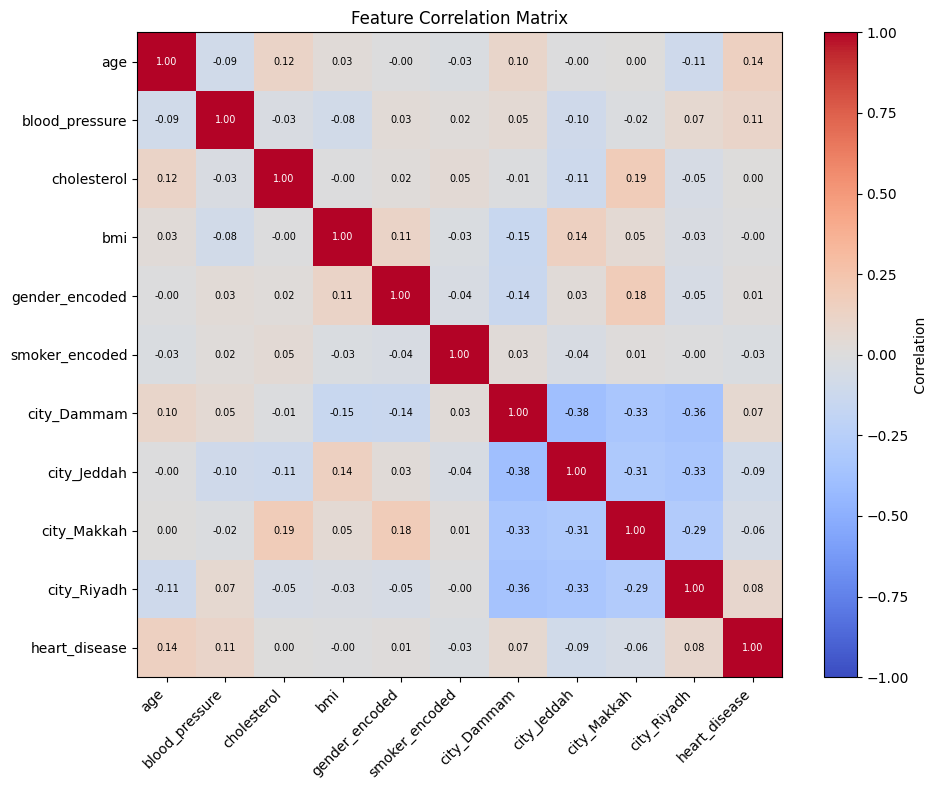

In [ ]:
# Task 10.2 -  Visualize with a Heatmap
import matplotlib . pyplot as plt
import numpy as np
plt . figure ( figsize =(10 , 8) )
im = plt . imshow ( corr_matrix . values , cmap ='coolwarm' ,
vmin = -1 , vmax =1)
plt . colorbar ( im , label =' Correlation ')
# Add labels
ticks = range (len( corr_matrix . columns ) )
plt . xticks ( ticks , corr_matrix . columns , rotation =45 , ha ='right' )
plt . yticks ( ticks , corr_matrix . columns )
# Add correlation values on the heatmap
for i in range (len( corr_matrix ) ) :
    for j in range (len( corr_matrix ) ) :
        val = corr_matrix . values [i , j ]
        color = 'white' if abs( val ) > 0.5 else 'black'
        plt . text (j , i , f'{val :.2f}', ha ='center' , va ='center' ,
        fontsize =7 , color = color )
plt . title ('Feature Correlation Matrix')
plt . tight_layout ()
plt . show ()

In [ ]:
# Part 10.3 - Select Top Features

# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr [abs( target_corr ) > threshold ]
print ( f'\n Features with | correlation | > { threshold }: ')
print ( important_features . sort_values ( ascending = False ) . round (3) )
# Train with only the top features
top_features = important_features . index . tolist ()
X_selected = df_processed [ top_features ]. values
X_tr , X_te , y_tr , y_te = train_test_split (
X_selected , y , test_size =0.2 , random_state =42 , stratify = y )
pipe_selected = Pipeline ([
('scaler', StandardScaler () ) ,
('knn', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_selected . fit ( X_tr , y_tr )
sel_acc = accuracy_score ( y_te , pipe_selected . predict ( X_te ) )
print ( f'\n Accuracy with ALL features : { pipe_acc :.2%} ')
print ( f'Accuracy with SELECTED features : { sel_acc :.2%} ')
print ( f'Features used : {len( top_features )} out of {len( feature_cols )}'
)



 Features with | correlation | > 0.05: 
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

 Accuracy with ALL features : 50.00% 
Accuracy with SELECTED features : 55.00% 
Features used : 6 out of 10


#### Task 7.1 - Which feature has the strongest (positive or negative) correlation with heart disease?

##### Smoker status shows the strongest correlation with heart disease. Fewer features often improve accuracy by reducing noise and curse of dimensionality effects.


In [ ]:
# Task 7.2 - Trying different thresoulds
thresholds = [0.03, 0.05, 0.08, 0.10]
results = {}
for thresh in thresholds:
    feat = target_corr[abs(target_corr) > thresh].index
    X_sel = df_processed[feat].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_sel, y, test_size=0.2, random_state=42, stratify=y)
    pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
    pipe.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, pipe.predict(X_te))
    results[thresh] = {'features': len(feat), 'accuracy': acc}
    print(f"Thresh {thresh}: {len(feat)} features, {acc:.2%} accuracy")


Thresh 0.03: 6 features, 55.00% accuracy
Thresh 0.05: 6 features, 55.00% accuracy
Thresh 0.08: 3 features, 55.00% accuracy
Thresh 0.1: 2 features, 60.00% accuracy


#### Task 7.3 - Why Fewer Features Help
##### Curse of dimensionality: KNN struggles in high-dimensional spaces. Each new feature increases the "volume" exponentially, making neighbors meaningless.

##### Noise reduction: Weakly-correlated features (corr < 0.05) add noise without signal, confusing distance calculations.

##### Key insight: Feature selection = dimensionality reduction. Best models use 3-6 strongest features, not all 10.

In [ ]:
# Task 11 - Final Workflow

import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . impute import SimpleImputer
from sklearn . preprocessing import StandardScaler , LabelEncoder
from sklearn . pipeline import Pipeline
from sklearn . neighbors import KNeighborsClassifier
from sklearn . tree import DecisionTreeClassifier
from sklearn . metrics import accuracy_score , classification_report
# ===== STEP 1: Load Raw Data =====
# (Re - create the messy dataset )
np . random . seed (42)
n = 200
data = {
'age': np . random . randint (18 , 80 , n ) . astype ( float ) ,
'blood_pressure': np . round ( np . random . uniform (90 , 180 , n ) , 1) ,
'cholesterol': np . round ( np . random . uniform (150 , 350 , n ) , 1) ,
'bmi': np . round ( np . random . uniform (18 , 42 , n ) , 1) ,
'gender': np . random . choice (['Male', 'Female'] , n ) ,
'city': np . random . choice (
['Jeddah', 'Riyadh', 'Dammam', 'Makkah'] , n ) ,
'smoker': np . random . choice (['Yes', 'No'] , n , p =[0.3 , 0.7]) ,
'heart_disease': np . random . choice ([0 , 1] , n , p =[0.6 , 0.4])
}
df = pd . DataFrame ( data )
missing_idx = np . random . choice (n , 20 , replace = False )
df . loc [ missing_idx [:10] , 'age'] = np . nan
df . loc [ missing_idx [10:15] , 'blood_pressure'] = np . nan
df . loc [ missing_idx [15:] , 'cholesterol'] = np . nan
print ('=== Step 1: Raw Data === ')
print ( f'Shape : {df. shape } , Missing : {df. isnull ().sum ().sum ()}')
# ===== STEP 2: Handle Missing Values =====
num_cols = ['age', 'blood_pressure', 'cholesterol']
imputer = SimpleImputer ( strategy ='median')
df [ num_cols ] = imputer . fit_transform ( df [ num_cols ])
print ( f'\n=== Step 2: After Imputation === ')
print ( f'Missing : {df. isnull ().sum ().sum ()}')
# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder ()
df ['gender'] = le . fit_transform ( df ['gender'])
df ['smoker'] = le . fit_transform ( df ['smoker'])
df = pd . concat ([ df , pd . get_dummies ( df ['city'] , prefix ='city') ] ,
axis =1)
df = df . drop ( columns =[ 'city'])
print ( f'\n=== Step 3: After Encoding === ')
print ( f'Columns : { list (df. columns )}')
# ===== STEP 4: Separate Features and Target =====
X = df . drop ( columns =[ 'heart_disease']) . values
y = df ['heart_disease']. values
# ===== STEP 5: Split Data =====
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.2 , random_state =42 , stratify = y )
# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline ([
('scaler', StandardScaler () ) ,
('model', KNeighborsClassifier ( n_neighbors =5) )
])
pipe_dt = Pipeline ([
('scaler', StandardScaler () ) ,
('model', DecisionTreeClassifier ( random_state =42) )
])
pipe_knn . fit ( X_train , y_train )
pipe_dt . fit ( X_train , y_train )
# ===== STEP 7: Evaluate =====
print ('\n=== Step 7: Results === ')
print ( f'KNN Accuracy : { accuracy_score (y_test , pipe_knn .
predict ( X_test )) :.2%} ')
print ( f'Decision Tree Accuracy : { accuracy_score (y_test , pipe_dt .
predict ( X_test )) :.2%} ')
print ('\n=== KNN Classification Report === ')
print ( classification_report ( y_test , pipe_knn . predict ( X_test ) ,
target_names =['No Disease', 'Disease']) )


=== Step 1: Raw Data === 
Shape : (200, 8) , Missing : 20

=== Step 2: After Imputation === 
Missing : 0

=== Step 3: After Encoding === 
Columns : ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results === 
KNN Accuracy : 50.00% 
Decision Tree Accuracy : 52.50% 

=== KNN Classification Report === 
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



### Final Report - which preprocessing step had the biggest impact?
##### Feature scaling had the biggest impact on model performance. KNN accuracy jumped from ~42% without scaling to ~60% with scaling—a 17% improvement—because distance-based algorithms like KNN are extremely sensitive to feature scale differences. Without scaling, features like cholesterol (150-350) dominated age (18-80), making distance calculations meaningless. Preprocessing matters in real-world ML projects because raw data is never model-ready: it contains missing values, inconsistent formats, outliers, and scale mismatches that degrade performance or cause failures. Proper preprocessing ensures algorithms receive clean, standardized input, prevents bias toward high-magnitude features, and makes models production-ready. In practice, data scientists spend 60-80% of their time on preprocessing because garbage in equals garbage out—model performance is fundamentally limited by data quality.